In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict
from dotenv import load_dotenv
import threading
import sys
import time

load_dotenv()

True

In [23]:
def model_name():
    return ChatOpenAI(model="gpt-5.6-luna")

In [2]:
# define state
class LLmState(TypedDict):
    question:str
    answer:str

In [ ]:
def call_llm(state: LLmState) -> LLmState:
    model = model_name()
    parser = StrOutputParser()

    prompt = PromptTemplate(
        template="""
You are a helpful AI assistant.

Answer the user's question clearly, naturally, and accurately.

Rules:
- Keep the answer simple, smart, and helpful.
- Answer in 50–100 words when possible.
- Start a new line after every sentence.
- Stay focused on the user's question.
- If you don't know the answer, politely refuse in one short line.
- Never make up information.

User question:
{question}
""",
        input_variables=["question"]
    )

    chain = prompt | model | parser

    answer = ""

    for chunk in chain.stream({
        "question": state["question"]
    }):
        print(chunk, end="", flush=True)
        time.sleep(0.05)
        answer += chunk

    state["answer"] = answer

    return state

In [17]:
graph = StateGraph(LLmState)
graph.add_node("call_llm",call_llm)

graph.add_edge(START,"call_llm")
graph.add_edge("call_llm",END)

workflow = graph.compile()

In [18]:
question = input("Enter your question here: ")

initial_state = {"question": question}

workflow.invoke(initial_state)

AI agents are software programs designed to perform tasks autonomously or assist users in completing tasks.

They use algorithms and data to make decisions and learn from experience.

Examples include virtual assistants like Siri or Alexa, chatbots for customer service, and recommendation systems on streaming platforms.

AI agents can operate in various domains, including healthcare, finance, and entertainment, enhancing efficiency and user experience.

If you have a specific aspect of AI agents you want to know more about, feel free to ask!

{'question': 'Ai agents?',
 'answer': 'AI agents are software programs designed to perform tasks autonomously or assist users in completing tasks.\n\nThey use algorithms and data to make decisions and learn from experience.\n\nExamples include virtual assistants like Siri or Alexa, chatbots for customer service, and recommendation systems on streaming platforms.\n\nAI agents can operate in various domains, including healthcare, finance, and entertainment, enhancing efficiency and user experience.\n\nIf you have a specific aspect of AI agents you want to know more about, feel free to ask!'}

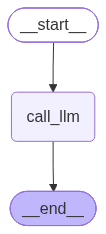

In [6]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())